Bismillah
Rabi Zindi Ilma


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Housing Dataset load karna
df = pd.read_csv('Housing.csv')

# Dataset overview
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
# Instructions ke mutabiq numeric columns ko features select karna
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Target variable (price) aur Features (X) divide karna
features = [col for col in numeric_cols if col != 'price']
X = df[features]
y = df['price']

print("Selected Numeric Features:", features)
print("Target Column:", 'price')

# Data ko Train aur Test sets mein split karna (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

Selected Numeric Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Target Column: price
Training Samples: 436 | Testing Samples: 109


In [3]:
# Model initialize aur train karna
model = LinearRegression()
model.fit(X_train, y_train)

print("Housing Price Linear Regression Model Trained Successfully!")

Housing Price Linear Regression Model Trained Successfully!


In [4]:
# Test data par price predict karna
y_pred = model.predict(X_test)

# Metrics calculation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- MODEL EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE)  : {mae:,.2f}")
print(f"Mean Squared Error (MSE)   : {mse:,.2f}")
print(f"Root Mean Squared Error    : {rmse:,.2f}")
print(f"R² Score (Accuracy)        : {r2:.4f} ({r2*100:.2f}%)")

--- MODEL EVALUATION METRICS ---
Mean Absolute Error (MAE)  : 1,127,483.35
Mean Squared Error (MSE)   : 2,292,721,545,725.36
Root Mean Squared Error    : 1,514,173.55
R² Score (Accuracy)        : 0.5464 (54.64%)


,Actual Price,Predicted Price,Difference (Error)
0,4060000,6178627.50,2118627.50
1,6650000,6370140.86,279859.14
2,3710000,3283148.16,426851.84
3,6440000,4226007.95,2213992.05
4,2800000,3409685.55,609685.55
5,4900000,4262158.35,637841.65
6,5250000,5493440.53,243440.53
7,4543000,5559897.74,1016897.74
8,2450000,3373715.42,923715.42
9,3353000,3020513.19,332486.81


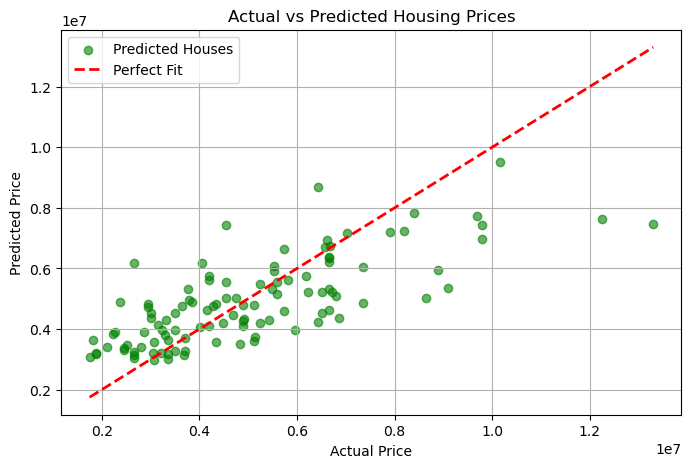

In [5]:
# Comparison table for top 10 test predictions
results_df = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': np.round(y_pred[:10], 2),
    'Difference (Error)': np.round(np.abs(y_test.values[:10] - y_pred[:10]), 2)
})

display(results_df)

# Actual vs Predicted Graph
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='green', alpha=0.6, label='Predicted Houses')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Perfect Fit')
plt.title('Actual vs Predicted Housing Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.show()